## Digit Classifier with CNN using PyTorch

### 1. Import Libraries and Load Data

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# Define a transformation to normalize the data and convert to tensor
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)) # MNIST mean and std
])

# Load the MNIST dataset
train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST('./data', train=False, download=True, transform=transform)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of test samples: {len(test_dataset)}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 59.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.76MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.6MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.8MB/s]

Number of training samples: 60000
Number of test samples: 10000


### 2. Define the CNN Model Architecture in PyTorch

In [ ]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2)
        self.dropout = nn.Dropout(0.5)
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(64 * 5 * 5, 128) # After two pooling layers, image size is 5x5
        self.relu3 = nn.ReLU()
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.dropout(x)
        x = self.flatten(x)
        x = self.relu3(self.fc1(x))
        x = self.fc2(x)
        return x

# Instantiate the model
model_pt = CNN()

# Check for GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_pt.to(device)

print(model_pt)

CNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.5, inplace=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=1600, out_features=128, bias=True)
  (relu3): ReLU()
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


### 3. Define Loss Function, Optimizer, and Train the Model

In [ ]:
# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_pt.parameters(), lr=0.001)

# Training loop
def train(model, device, train_loader, optimizer, epoch):
    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        if batch_idx % 100 == 0:
            print(f'Train Epoch: {epoch} [{batch_idx * len(data)}/{len(train_loader.dataset)} ({100. * batch_idx / len(train_loader):.0f}%)]\tLoss: {loss.item():.6f}')

# Test loop
def test(model, device, test_loader):
    model.eval()
    test_loss = 0
    correct = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += criterion(output, target).item() # sum up batch loss
            pred = output.argmax(dim=1, keepdim=True) # get the index of the max log-probability
            correct += pred.eq(target.view_as(pred)).sum().item()

    test_loss /= len(test_loader.dataset)

    print(f'\nTest set: Average loss: {test_loss:.4f}, Accuracy: {correct}/{len(test_loader.dataset)} ({100. * correct / len(test_loader.dataset):.0f}%)\n')
    return 100. * correct / len(test_loader.dataset)

# Train the model
epochs = 5
accuracies = []
for epoch in range(1, epochs + 1):
    train(model_pt, device, train_loader, optimizer, epoch)
    accuracy = test(model_pt, device, test_loader)
    accuracies.append(accuracy)

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.318193
Train Epoch: 1 [6400/60000 (11%)]	Loss: 0.167964
Train Epoch: 1 [12800/60000 (21%)]	Loss: 0.263378
Train Epoch: 1 [19200/60000 (32%)]	Loss: 0.245336
Train Epoch: 1 [25600/60000 (43%)]	Loss: 0.137479
Train Epoch: 1 [32000/60000 (53%)]	Loss: 0.038238
Train Epoch: 1 [38400/60000 (64%)]	Loss: 0.054801
Train Epoch: 1 [44800/60000 (75%)]	Loss: 0.133462
Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.052280
Train Epoch: 1 [57600/60000 (96%)]	Loss: 0.029870

Test set: Average loss: 0.0000, Accuracy: 9849/10000 (98%)

Train Epoch: 2 [0/60000 (0%)]	Loss: 0.209045
Train Epoch: 2 [6400/60000 (11%)]	Loss: 0.121514
Train Epoch: 2 [12800/60000 (21%)]	Loss: 0.050255
Train Epoch: 2 [19200/60000 (32%)]	Loss: 0.160233
Train Epoch: 2 [25600/60000 (43%)]	Loss: 0.116479
Train Epoch: 2 [32000/60000 (53%)]	Loss: 0.036091
Train Epoch: 2 [38400/60000 (64%)]	Loss: 0.015299
Train Epoch: 2 [44800/60000 (75%)]	Loss: 0.049883
Train Epoch: 2 [51200/60000 (85%)]	Loss: 0.070078
T

### 4. Visualize Results (Optional)

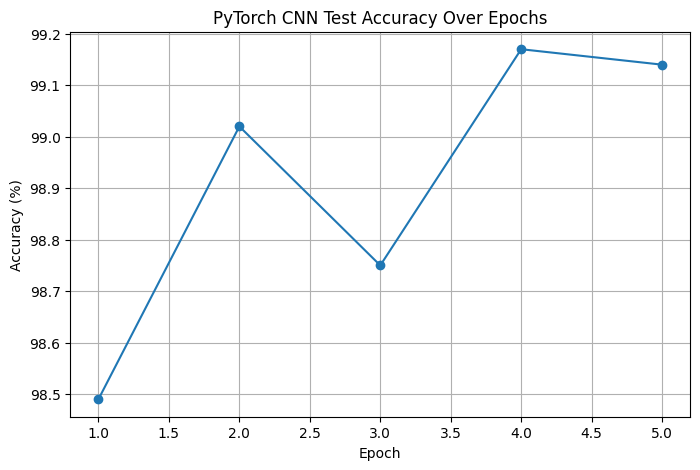

In [ ]:
# Plotting the training accuracy over epochs
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), accuracies, marker='o')
plt.title('PyTorch CNN Test Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.grid(True)
plt.show()

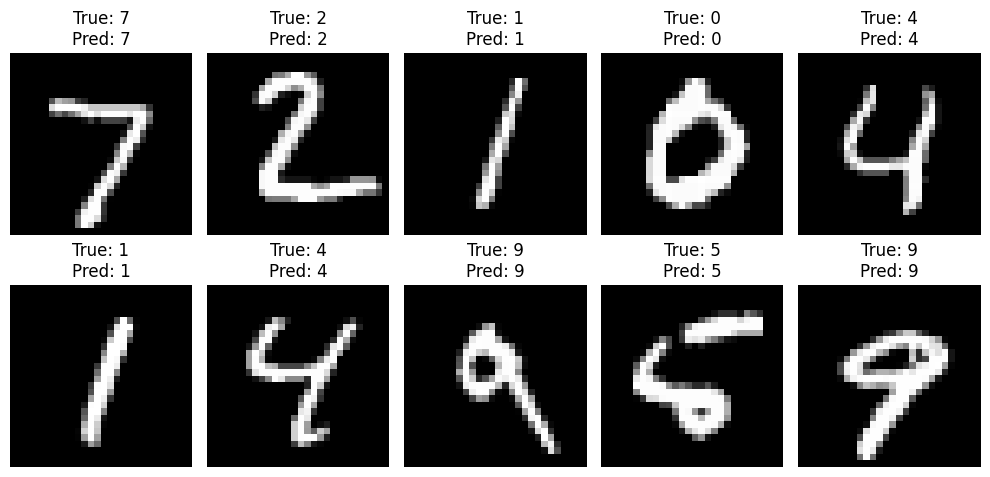

In [ ]:
# Make some predictions (optional)
model_pt.eval()
with torch.no_grad():
    data, target = next(iter(test_loader)) # Get a batch of test data
    data, target = data.to(device), target.to(device)
    output = model_pt(data)
    predictions = output.argmax(dim=1, keepdim=True)

# Display the first 10 test images with their true and predicted labels
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(data[i].cpu().reshape(28, 28), cmap='gray')
    plt.title(f"True: {target[i].item()}\nPred: {predictions[i].item()}")
    plt.axis('off')
plt.tight_layout()
plt.show()